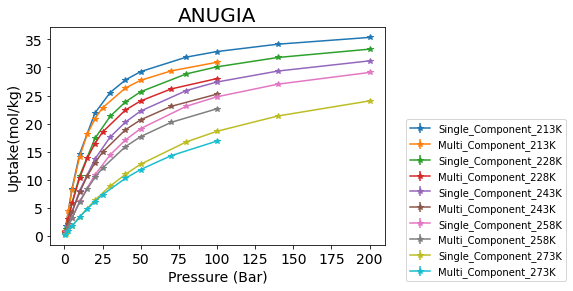

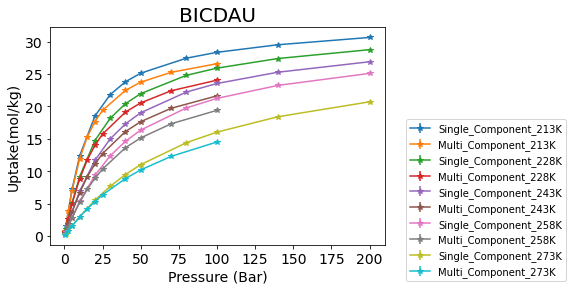

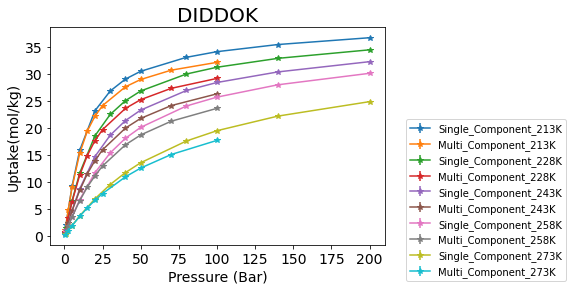

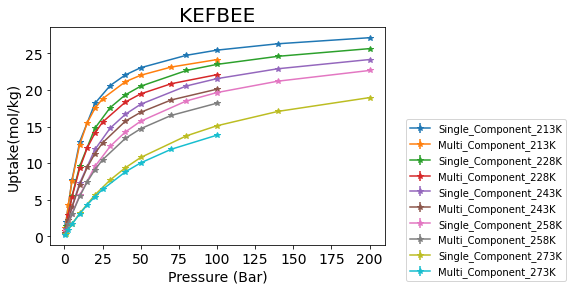

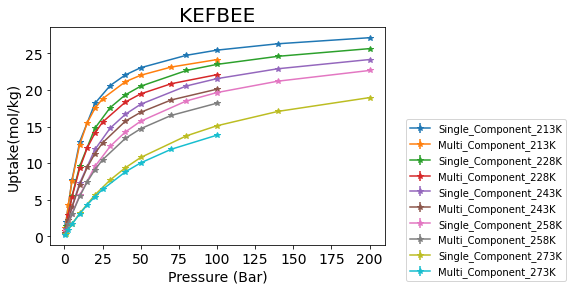

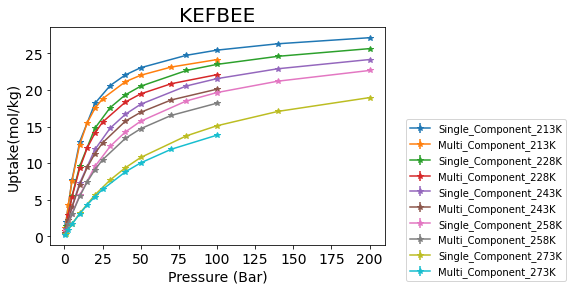

In [3]:
import numpy as np
import os, glob
import pandas as pd
import matplotlib.pyplot as plt
import re

parent_dir_ANUGIA_SC = '/Users/shubhamjamdade/Desktop/mnt/phoenix/RASPA2-master/examples/Non-Basic/hive_data/O2_He_Before_Screening/O2_Nature/ANUGIA/'
parent_dir_BICDAU_SC = '/Users/shubhamjamdade/Desktop/mnt/phoenix/RASPA2-master/examples/Non-Basic/hive_data/O2_He_Before_Screening/O2_Nature/BICDAU/'
parent_dir_DIDDOK_SC = '/Users/shubhamjamdade/Desktop/mnt/phoenix/RASPA2-master/examples/Non-Basic/hive_data/O2_He_Before_Screening/O2_Nature/DIDDOK/'
parent_dir_KFEBEE_SC = '/Users/shubhamjamdade/Desktop/mnt/phoenix/RASPA2-master/examples/Non-Basic/hive_data/O2_He_Before_Screening/O2_Nature/KFEBEE/'


parent_dir_ANUGIA_MC = '/Users/shubhamjamdade/Desktop/mnt/phoenix/RASPA2-master/examples/Non-Basic/hive_data/O2_He_Before_Screening/O2_Nature/O2_He_mixture/ANUGIA_m/'
parent_dir_BICDAU_MC = '/Users/shubhamjamdade/Desktop/mnt/phoenix/RASPA2-master/examples/Non-Basic/hive_data/O2_He_Before_Screening/O2_Nature/O2_He_mixture/BICDAU_m/'
parent_dir_DIDDOK_MC = '/Users/shubhamjamdade/Desktop/mnt/phoenix/RASPA2-master/examples/Non-Basic/hive_data/O2_He_Before_Screening/O2_Nature/O2_He_mixture/DIDDOK_m/'
parent_dir_KFEBEE_MC = '/Users/shubhamjamdade/Desktop/mnt/phoenix/RASPA2-master/examples/Non-Basic/hive_data/O2_He_Before_Screening/O2_Nature/O2_He_mixture/KFEBEE_m/'

T = ['213', '228', '243', '258', '298']

for i in range (1,7):

    if i == 1:
       list = [str(parent_dir_ANUGIA_SC), str(parent_dir_ANUGIA_MC)]
    
    if i == 2:
       list = [str(parent_dir_BICDAU_SC), str(parent_dir_BICDAU_MC)]

    if i == 3:
       list = [str(parent_dir_DIDDOK_SC), str(parent_dir_DIDDOK_MC)]

    if i == 4:
       list = [str(parent_dir_KFEBEE_SC), str(parent_dir_KFEBEE_MC)]
    

    for value in T:
        
        
        for d in list:
        
            absolute_uptake_avg=[]
            std=[]
            absolute_uptake_avg_O2 = []
            title = None
            for j in range(1,12):


                path_MOFs = os.path.join(d, str(value), str(j), 'Output', 'System_0')

                os.chdir(path_MOFs)

                for file in glob.glob("*.data"):

                    f = open(file,'r')
                    lines=f.readlines()
                    f.close()
                    for line in lines:
                      row=line.split()

                      if not line.strip():
                         continue


                      if len(row)==9 and row[0] == 'Average' and row[1] == 'loading' and row[2] == 'absolute' and row[3] == '[mol/kg':
                         absolute_uptake_avg.append(float(row[5]))
                         std.append(float(row[7]))


                      if len(row)==3 and row[0] == 'Framework' and row[1] == 'name:' :
                         title = str(row[2])



            plt.figure(i)


            x = np.array([1.0, 5.0, 10.0, 20.0, 30.0, 40.0, 50.0, 80.0, 100.0, 140.0, 200.0])

            y = np.array(absolute_uptake_avg)

            err = np.array(std)
            
            


            if d == str(parent_dir_ANUGIA_MC) or d == str(parent_dir_BICDAU_MC) or d == str(parent_dir_DIDDOK_MC) or d == str(parent_dir_KFEBEE_MC) :
                absolute_uptake_avg_O2 = absolute_uptake_avg[::2]
                x  = np.divide(x, 2)
                y = np.array(absolute_uptake_avg_O2)
                std_O2 = std[::2]
                err = np.array(std_O2)

            plt.errorbar(x, y, yerr=err, marker='*')

            plt.xlabel("Pressure (Bar)", fontsize=14)

            plt.ylabel("Uptake(mol/kg)", fontsize=14)

            plt.legend(['Single_Component_213K' , 'Multi_Component_213K' ,'Single_Component_228K', 'Multi_Component_228K', 'Single_Component_243K', 'Multi_Component_243K','Single_Component_258K', 'Multi_Component_258K','Single_Component_273K', 'Multi_Component_273K','Single_Component_298K', 'Multi_Component_298K'], bbox_to_anchor = (1.05, 0.6))

            plt.xticks(fontsize=14)

            plt.yticks(fontsize=14)

            plt.title(str(title), fontsize=20)


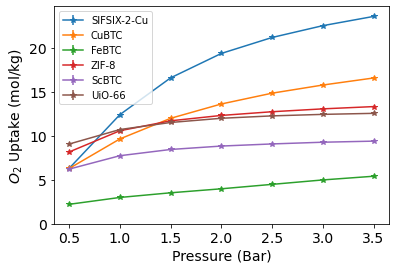

In [7]:
import numpy as np
import os, glob
import pandas as pd
import matplotlib.pyplot as plt
import re

parent_dir_ScBTC_MC = '/Users/shubhamjamdade/Desktop/mnt/phoenix/RASPA2-master/examples/Non-Basic/hive_data/O2_He_Before_Screening/TDA/ScBTC_test/'
parent_dir_FeBTC_MC = '/Users/shubhamjamdade/Desktop/mnt/phoenix/RASPA2-master/examples/Non-Basic/hive_data/O2_He_Before_Screening/TDA/FeBTC_test/'
parent_dir_CuBTC_MC = '/Users/shubhamjamdade/Desktop/mnt/phoenix/RASPA2-master/examples/Non-Basic/hive_data/O2_He_Before_Screening/TDA/CuBTC_test/'
parent_dir_SIFSIX_2_Cu_MC = '/Users/shubhamjamdade/Desktop/mnt/phoenix/RASPA2-master/examples/Non-Basic/hive_data/O2_He_Before_Screening/TDA/SIFSIX-2-Cu_test/'
#parent_dir_SIFSIX_2_Cu_i_MC = '/Users/shubhamjamdade/Desktop/mnt/phoenix/RASPA2-master/examples/Non-Basic/hive_data/O2_He_Before_Screening/TDA/SIFSIX-2-Cu-i_test/'
parent_dir_UIO66_MC = '/Users/shubhamjamdade/Desktop/mnt/phoenix/RASPA2-master/examples/Non-Basic/hive_data/O2_He_Before_Screening/TDA/UIO66_test/'
parent_dir_ZIF8_MC = '/Users/shubhamjamdade/Desktop/mnt/phoenix/RASPA2-master/examples/Non-Basic/hive_data/O2_He_Before_Screening/TDA/ZIF8_test/'


list = [str(parent_dir_SIFSIX_2_Cu_MC), str(parent_dir_CuBTC_MC), str(parent_dir_FeBTC_MC), str(parent_dir_ZIF8_MC),  str(parent_dir_ScBTC_MC), str(parent_dir_UIO66_MC)]
k = 0
for d in list:
    k = k + 1
    
    absolute_uptake_avg=[]
    std=[]
    title = None
    for j in range(1,8):
        
        
        path_MOFs = os.path.join(d, str(j), 'Output', 'System_0')
        
        os.chdir(path_MOFs)
        
        for file in glob.glob("*.data"):
            
            f = open(file,'r')
            lines=f.readlines()
            f.close()
            for line in lines:
              row=line.split()

              if not line.strip():
                 continue


              if len(row)==9 and row[0] == 'Average' and row[1] == 'loading' and row[2] == 'absolute' and row[3] == '[mol/kg':
                 absolute_uptake_avg.append(float(row[5]))
                 std.append(float(row[7]))
                
                
              if len(row)==3 and row[0] == 'Framework' and row[1] == 'name:' :
                 title = str(row[2])
                 

        
    plt.figure(1)
    
        
    x = np.array([0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5])

    absolute_uptake_avg_O2 = absolute_uptake_avg[1::2]
    y = np.array(absolute_uptake_avg_O2)
    std_O2 = std[1::2]
    err = np.array(std_O2)

    plt.errorbar(x, y, yerr=err, marker='*')
        
    plt.xlabel("Pressure (Bar)", fontsize=14)
        
    plt.ylabel('$O_{2}$ Uptake (mol/kg)', fontsize=14)
    
    plt.yticks(np.arange(0, 25, step=5))
        
    plt.legend(['SIFSIX-2-Cu', 'CuBTC', 'FeBTC', 'ZIF-8',   'ScBTC', 'UiO-66'])
        
    plt.xticks(fontsize=14)
    
    plt.yticks(fontsize=14)
        
    plt.title(str(), fontsize=20)


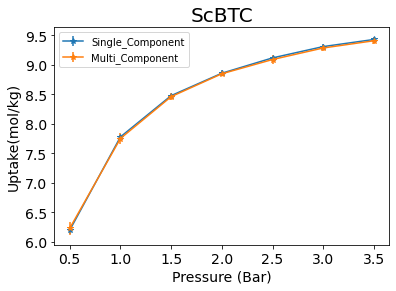

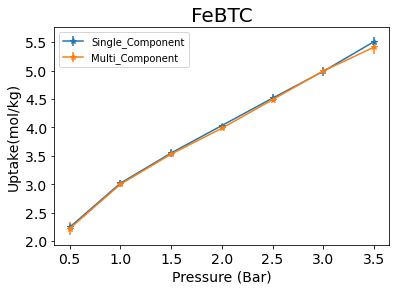

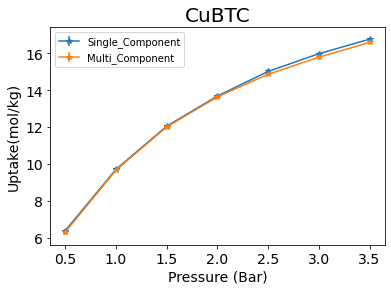

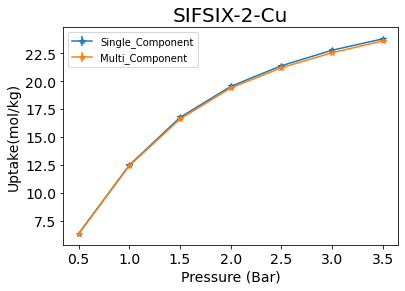

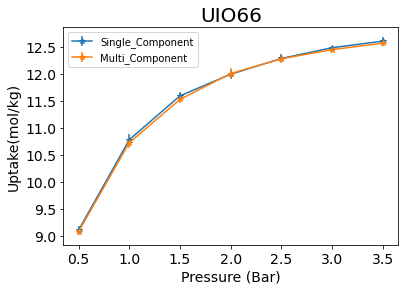

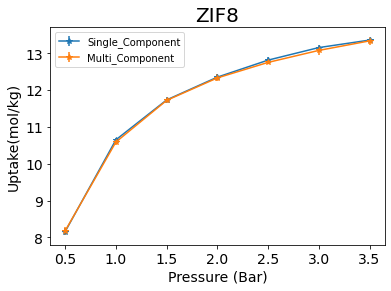

In [4]:
import numpy as np
import os, glob
import pandas as pd
import matplotlib.pyplot as plt
import re

parent_dir_ScBTC_SC = '/Users/shubhamjamdade/Desktop/mnt/phoenix/RASPA2-master/examples/Non-Basic/hive_data/O2_He_Before_Screening/TDA/single_component_f/ScBTC_test/'
parent_dir_FeBTC_SC = '/Users/shubhamjamdade/Desktop/mnt/phoenix/RASPA2-master/examples/Non-Basic/hive_data/O2_He_Before_Screening/TDA/single_component_f/FeBTC_test/'
parent_dir_CuBTC_SC = '/Users/shubhamjamdade/Desktop/mnt/phoenix/RASPA2-master/examples/Non-Basic/hive_data/O2_He_Before_Screening/TDA/single_component_f/CuBTC_test/'
parent_dir_SIFSIX_2_Cu_SC = '/Users/shubhamjamdade/Desktop/mnt/phoenix/RASPA2-master/examples/Non-Basic/hive_data/O2_He_Before_Screening/TDA/single_component_f/SIFSIX-2-Cu_test/'
#parent_dir_SIFSIX_2_Cu_i = '/Users/shubhamjamdade/Desktop/mnt/phoenix/RASPA2-master/examples/Non-Basic/hive_data/O2_He_Before_Screening/TDA/single_component_f/SIFSIX-2-Cu-i_test/'
parent_dir_UIO66_SC = '/Users/shubhamjamdade/Desktop/mnt/phoenix/RASPA2-master/examples/Non-Basic/hive_data/O2_He_Before_Screening/TDA/single_component_f/UIO66_test/'
parent_dir_ZIF8_SC = '/Users/shubhamjamdade/Desktop/mnt/phoenix/RASPA2-master/examples/Non-Basic/hive_data/O2_He_Before_Screening/TDA/single_component_f/ZIF8_test/'

parent_dir_ScBTC_MC = '/Users/shubhamjamdade/Desktop/mnt/phoenix/RASPA2-master/examples/Non-Basic/hive_data/O2_He_Before_Screening/TDA/ScBTC_test/'
parent_dir_FeBTC_MC = '/Users/shubhamjamdade/Desktop/mnt/phoenix/RASPA2-master/examples/Non-Basic/hive_data/O2_He_Before_Screening/TDA/FeBTC_test/'
parent_dir_CuBTC_MC = '/Users/shubhamjamdade/Desktop/mnt/phoenix/RASPA2-master/examples/Non-Basic/hive_data/O2_He_Before_Screening/TDA/CuBTC_test/'
parent_dir_SIFSIX_2_Cu_MC = '/Users/shubhamjamdade/Desktop/mnt/phoenix/RASPA2-master/examples/Non-Basic/hive_data/O2_He_Before_Screening/TDA/SIFSIX-2-Cu_test/'
#parent_dir_SIFSIX_2_Cu_i_MC = '/Users/shubhamjamdade/Desktop/mnt/phoenix/RASPA2-master/examples/Non-Basic/hive_data/O2_He_Before_Screening/TDA/SIFSIX-2-Cu-i_test/'
parent_dir_UIO66_MC = '/Users/shubhamjamdade/Desktop/mnt/phoenix/RASPA2-master/examples/Non-Basic/hive_data/O2_He_Before_Screening/TDA/UIO66_test/'
parent_dir_ZIF8_MC = '/Users/shubhamjamdade/Desktop/mnt/phoenix/RASPA2-master/examples/Non-Basic/hive_data/O2_He_Before_Screening/TDA/ZIF8_test/'


for i in range (1,7):

    if i == 1:
       list = [str(parent_dir_ScBTC_SC), str(parent_dir_ScBTC_MC)]
    
    if i == 2:
       list = [str(parent_dir_FeBTC_SC), str(parent_dir_FeBTC_MC)]

    if i == 3:
       list = [str(parent_dir_CuBTC_SC), str(parent_dir_CuBTC_MC)]

    if i == 4:
       list = [str(parent_dir_SIFSIX_2_Cu_SC), str(parent_dir_SIFSIX_2_Cu_MC)]

    if i == 5:
       list = [str(parent_dir_UIO66_SC), str(parent_dir_UIO66_MC)]

    if i == 6:
       list = [str(parent_dir_ZIF8_SC), str(parent_dir_ZIF8_MC)]

    for d in list:
        absolute_uptake_avg=[]
        std=[]
        absolute_uptake_avg_O2 = []
        title = None
        for j in range(1,8):
        
        
            path_MOFs = os.path.join(d, str(j), 'Output', 'System_0')
        
            os.chdir(path_MOFs)
        
            for file in glob.glob("*.data"):
            
                f = open(file,'r')
                lines=f.readlines()
                f.close()
                for line in lines:
                  row=line.split()

                  if not line.strip():
                     continue


                  if len(row)==9 and row[0] == 'Average' and row[1] == 'loading' and row[2] == 'absolute' and row[3] == '[mol/kg':
                     absolute_uptake_avg.append(float(row[5]))
                     std.append(float(row[7]))
                
                
                  if len(row)==3 and row[0] == 'Framework' and row[1] == 'name:' :
                     title = str(row[2])
                 


        plt.figure(i)


        x = np.array([0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5])
        
        y = np.array(absolute_uptake_avg)
        
        err = np.array(std)
        
        
        if d == str(parent_dir_ScBTC_MC) or d == str(parent_dir_FeBTC_MC) or d == str(parent_dir_CuBTC_MC) or d == str(parent_dir_SIFSIX_2_Cu_MC) or d == str(parent_dir_UIO66_MC) or d == str(parent_dir_ZIF8_MC):
            absolute_uptake_avg_O2 = absolute_uptake_avg[1::2]
            y = np.array(absolute_uptake_avg_O2)
            std_O2 = std[1::2]
            err = np.array(std_O2)

        plt.errorbar(x, y, yerr=err, marker='*')

        plt.xlabel("Pressure (Bar)", fontsize=14)

        plt.ylabel("Uptake(mol/kg)", fontsize=14)

        plt.legend(['Single_Component', 'Multi_Component'])

        plt.xticks(fontsize=14)

        plt.yticks(fontsize=14)

        plt.title(str(title), fontsize=20)


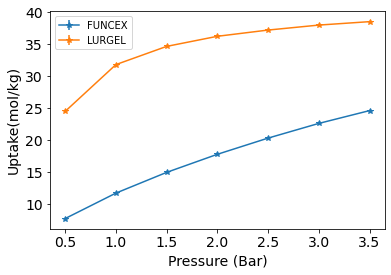

In [2]:
import numpy as np
import os, glob
import pandas as pd
import matplotlib.pyplot as plt
import re

parent_dir_10 = '/Users/shubhamjamdade/Desktop/mnt/phoenix/RASPA2-master/examples/Non-Basic/O2_He/top_11_MOFs/GCMC/Isotherms/10_opt'

parent_dir_11 = '/Users/shubhamjamdade/Desktop/mnt/phoenix/RASPA2-master/examples/Non-Basic/O2_He/top_11_MOFs/GCMC/Isotherms/11_opt'


for i in range (1,2):

    if i == 1:
       list = [str(parent_dir_10), str(parent_dir_11)]
    
    if i == 2:
       list = [str(parent_dir_FeBTC_SC), str(parent_dir_FeBTC_MC)]

    if i == 3:
       list = [str(parent_dir_CuBTC_SC), str(parent_dir_CuBTC_MC)]

    if i == 4:
       list = [str(parent_dir_SIFSIX_2_Cu_SC), str(parent_dir_SIFSIX_2_Cu_MC)]

    if i == 5:
       list = [str(parent_dir_UIO66_SC), str(parent_dir_UIO66_MC)]

    if i == 6:
       list = [str(parent_dir_ZIF8_SC), str(parent_dir_ZIF8_MC)]

    for d in list:
        absolute_uptake_avg=[]
        std=[]
        absolute_uptake_avg_O2 = []
        title = None
        for j in range(1,8):
        
        
            path_MOFs = os.path.join(d, str(j), 'Output', 'System_0')
        
            os.chdir(path_MOFs)
        
            for file in glob.glob("*.data"):
            
                f = open(file,'r')
                lines=f.readlines()
                f.close()
                for line in lines:
                  row=line.split()

                  if not line.strip():
                     continue


                  if len(row)==9 and row[0] == 'Average' and row[1] == 'loading' and row[2] == 'absolute' and row[3] == '[mol/kg':
                     absolute_uptake_avg.append(float(row[5]))
                     std.append(float(row[7]))
                
                
                  if len(row)==3 and row[0] == 'Framework' and row[1] == 'name:' :
                     title = str(row[2])
                 


        plt.figure(i)


        x = np.array([0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5])
        
        y = np.array(absolute_uptake_avg)
        
        err = np.array(std)
        
        
        if d == str(parent_dir_10) or d == str(parent_dir_11):
            absolute_uptake_avg_O2 = absolute_uptake_avg[1::2]
            y = np.array(absolute_uptake_avg_O2)
            std_O2 = std[1::2]
            err = np.array(std_O2)

        plt.errorbar(x, y, yerr=err, marker='*')

        plt.xlabel("Pressure (Bar)", fontsize=14)

        plt.ylabel("Uptake(mol/kg)", fontsize=14)

        plt.legend(['FUNCEX', 'LURGEL'])

        plt.xticks(fontsize=14)

        plt.yticks(fontsize=14)

        #plt.title(str(title) + '160K', fontsize=20)
